In [30]:
# 基本套件
import numpy as np
import pandas as pd

# 視覺化
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [31]:
# 載入資料
df = pd.read_csv("../data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
# 移除不必要欄位
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# 補 Age（中位數）
df["Age"] = df["Age"].fillna(df["Age"].median())

# 補 Embarked（眾數）
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 類別轉換
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

# target
df["Survived"] = df["Survived"].astype(int)

df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [33]:
# 家庭大小
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 是否單獨
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [34]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,True,False,True
1,1,1,38.0,1,0,71.2833,2,0,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,True


In [35]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)



In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8044692737430168

Confusion Matrix:
 [[97 13]
 [22 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [50]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, y_prob_lr))

AUC: 0.8511198945981555


In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [9]:
lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

y_pred_lda = lda_model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lda))
print("\nReport:\n", classification_report(y_test, y_pred_lda))

Accuracy: 0.8100558659217877

Confusion Matrix:
 [[97 13]
 [21 48]]

Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [11]:
y_prob_lda = lda_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_lda))

AUC: 0.8445322793148881


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

print("\nReport:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.8156424581005587

Confusion Matrix:
 [[97 13]
 [20 49]]

Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [20]:
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_knn))

AUC: 0.8484848484848486


In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
tree_model = DecisionTreeClassifier(
    max_depth=5,        # 防止過擬合（很重要）
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

print("\nReport:\n", classification_report(y_test, y_pred_tree))

Accuracy: 0.7597765363128491

Confusion Matrix:
 [[96 14]
 [29 40]]

Report:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.74      0.58      0.65        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.76      0.76      0.75       179



In [24]:
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_tree))

AUC: 0.8037549407114625


In [25]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [26]:
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,   # 對應 nbagg=50
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_bag))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))

print("\nReport:\n", classification_report(y_test, y_pred_bag))

Accuracy: 0.8156424581005587

Confusion Matrix:
 [[96 14]
 [19 50]]

Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [28]:
y_prob_bag = bag_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_bag))

AUC: 0.8307641633728591


In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=100,   # 對應 ntree=100
    random_state=42,
    max_depth=None
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nReport:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8212290502793296

Confusion Matrix:
 [[96 14]
 [18 51]]

Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [45]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_rf))

AUC: 0.8304347826086957


In [51]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
svm_model = SVC(
    kernel="rbf",      # 常用：rbf / linear
    probability=True,  # 對應 R 的 probability=TRUE
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

print("\nReport:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.8156424581005587

Confusion Matrix:
 [[100  10]
 [ 23  46]]

Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



In [55]:
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_svm))

AUC: 0.8372859025032938


In [56]:
import pandas as pd
from sklearn.metrics import accuracy_score, cohen_kappa_score

In [59]:
results = {
    "Logistic Regression": y_pred_lr,
    "LDA": y_pred_lda,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "Bagging": y_pred_bag,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

In [60]:
metrics = []

for model_name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    metrics.append([model_name, acc, kappa])

df_metrics = pd.DataFrame(metrics, columns=["Model", "Accuracy", "Kappa"])
df_metrics.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Kappa
5,Random Forest,0.821229,0.618540
4,Bagging,0.815642,0.605543
2,KNN,0.815642,0.603371
6,SVM,0.815642,0.596709
1,LDA,0.810056,0.590224
0,Logistic Regression,0.804469,0.577004
3,Decision Tree,0.759777,0.471541


In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [65]:
y_prob_lr = lr_model.predict_proba(X_test)[:,1]
y_prob_lda = lda_model.predict_proba(X_test)[:,1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]
y_prob_tree = tree_model.predict_proba(X_test)[:,1]
y_prob_bag = bag_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

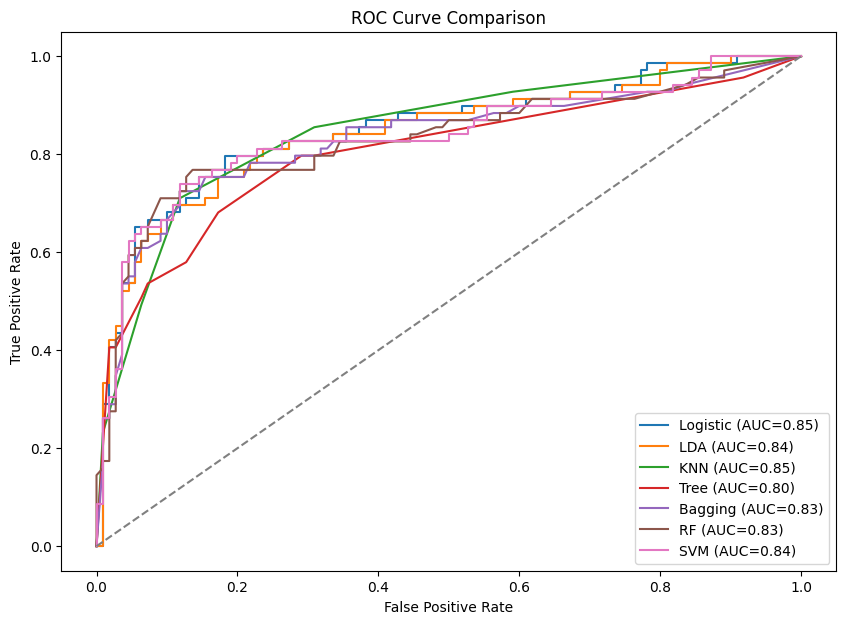

In [66]:
plt.figure(figsize=(10,7))

models = {
    "Logistic": y_prob_lr,
    "LDA": y_prob_lda,
    "KNN": y_prob_knn,
    "Tree": y_prob_tree,
    "Bagging": y_prob_bag,
    "RF": y_prob_rf,
    "SVM": y_prob_svm
}

for name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"--",color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [67]:
best_model = df_metrics.sort_values(by="Accuracy", ascending=False).iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
Accuracy         0.821229
Kappa             0.61854
Name: 5, dtype: object


In [68]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
4,Fare,0.264034
7,Sex_male,0.261230
1,Age,0.241361
0,Pclass,0.087441
5,FamilySize,0.044916
2,SibSp,0.028868
9,Embarked_S,0.025019
3,Parch,0.023795
6,IsAlone,0.012560
8,Embarked_Q,0.010777


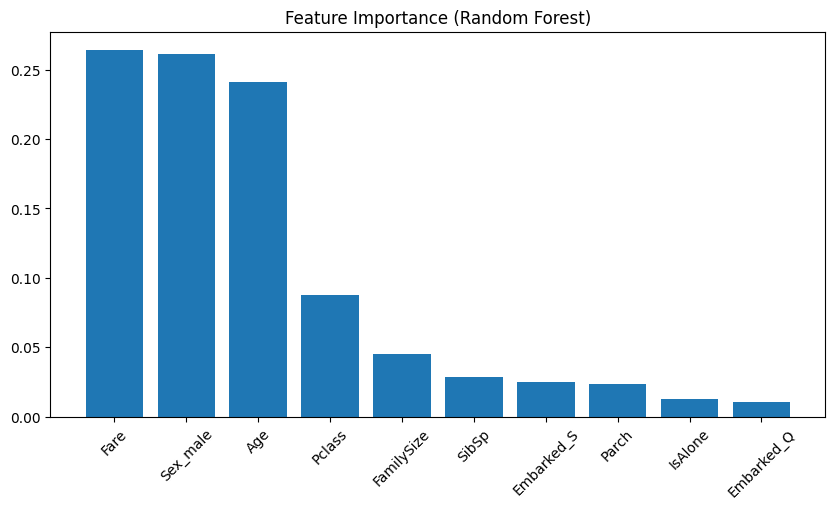

In [69]:
plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

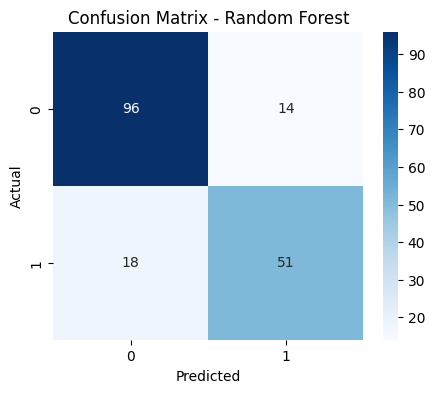

In [71]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()